In [1]:
!pip install matplotlib seaborn numpy


      ASTROPHYSICS STAR LIFELINE GENERATOR      


Enter Star Mass in Solar Masses (M☉) [0.08 to 150]:  150
Enter Metallicity (Z) relative to Sun [0.01 to 3.0]:  0.01
Does the star have a close binary companion? (yes/no):  no


/tmp/ipykernel_58/1311398815.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


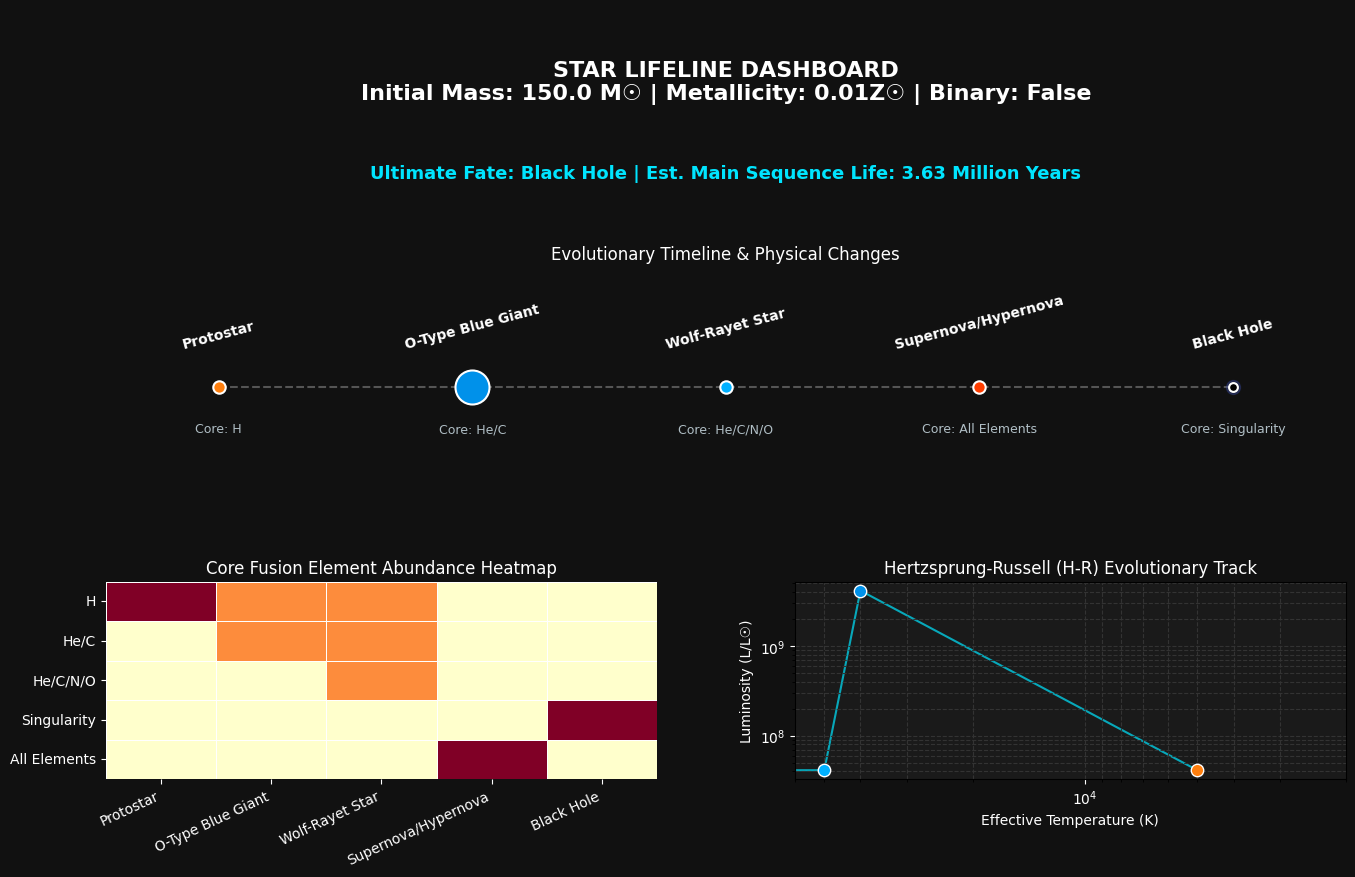

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

def get_user_inputs():
    print("="*50)
    print("      ASTROPHYSICS STAR LIFELINE GENERATOR      ")
    print("="*50)
    # 1. Mass input (The primary driver of stellar evolution)
    while True:
        try:
            mass = float(input("Enter Star Mass in Solar Masses (M☉) [0.08 to 150]: "))
            if 0.08 <= mass <= 150:
                break
            print("Please enter a mass between 0.08 and 150 M☉.")
        except ValueError:
            print("Invalid input. Please enter a number.")
            
    # 2. Metallicity (Fe/H ratio relative to Sun)
    while True:
        try:
            metallicity = float(input("Enter Metallicity (Z) relative to Sun [0.01 to 3.0]: "))
            if 0.01 <= metallicity <= 3.0:
                break
            print("Please enter a value between 0.01 and 3.0.")
        except ValueError:
            print("Invalid input.")

    # 3. Binary Companion (Affects the ultimate fate / Supernova type)
    has_companion = input("Does the star have a close binary companion? (yes/no): ").strip().lower() == 'yes'
    
    return mass, metallicity, has_companion

def calculate_stellar_properties(mass, metallicity, has_companion):
    # Main Sequence Lifetime scaling law: T ~ Mass^(-2.5) * 10 billion years
    # Adjusted slightly for metallicity (higher metallicity = shorter life due to opacity)
    ms_lifetime = (10000 / (mass ** 2.5)) * (1 / metallicity)
    
    # Define evolution stages, colors, temperatures, and sizes based on mass
    if mass < 0.4:
        fate = "White Dwarf (Helium)"
        stages = ["Protostar", "Blue Straggler / Red Dwarf", "Helium White Dwarf"]
        durations = [ms_lifetime * 0.01, ms_lifetime, ms_lifetime * 50] # Long lived
        colors = ['#ff7f0e', '#ff4f4f', '#e0e0e0']
        temps = [3000, 4000, 8000]
        elements = ['H', 'He', 'He']
    elif mass < 8:
        fate = "White Dwarf (Carbon-Oxygen)"
        stages = ["Protostar", "Main Sequence", "Red Giant", "Planetary Nebula", "C-O White Dwarf"]
        durations = [ms_lifetime * 0.01, ms_lifetime, ms_lifetime * 0.1, ms_lifetime * 0.001, ms_lifetime * 10]
        colors = ['#ff7f0e', '#fcd116', '#ff4f4f', '#00e5ff', '#ffffff']
        temps = [3500, 6000, 3000, 25000, 10000]
        elements = ['H', 'He', 'C/O', 'C/O', 'C/O']
    elif mass < 20:
        fate = "Neutron Star" if not has_companion else "Neutron Star / Pulsar (Mass Stripped)"
        stages = ["Protostar", "Blue Massive Star", "Red Supergiant", "Supernova Type II", "Neutron Star"]
        durations = [ms_lifetime * 0.005, ms_lifetime, ms_lifetime * 0.05, 0.0001, ms_lifetime * 5]
        colors = ['#ff7f0e', '#33b5e5', '#ff4f4f', '#ffea00', '#9c27b0']
        temps = [4000, 25000, 3200, 100000, 500000]
        elements = ['H', 'He', 'C/O/Ne/Mg/Si/Fe', 'Heavy Elements', 'Neutronium']
    else:
        fate = "Black Hole" if not has_companion else "Black Hole (Hypernova/GRB remnant)"
        stages = ["Protostar", "O-Type Blue Giant", "Wolf-Rayet Star", "Supernova/Hypernova", "Black Hole"]
        durations = [ms_lifetime * 0.002, ms_lifetime, ms_lifetime * 0.02, 0.0001, ms_lifetime * 10]
        colors = ['#ff7f0e', '#0091ea', '#00b0ff', '#ff3d00', '#000000']
        temps = [5000, 40000, 50000, 200000, 0]
        elements = ['H', 'He/C', 'He/C/N/O', 'All Elements', 'Singularity']

    return fate, stages, durations, colors, temps, elements, ms_lifetime

def plot_dashboard(mass, metallicity, has_companion, fate, stages, durations, colors, temps, elements, ms_lifetime):
    fig = plt.figure(figsize=(16, 10), facecolor='#111111')
    gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1.5, 1.3], hspace=0.4, wspace=0.25)

    ax_title = fig.add_subplot(gs[0, :], facecolor='none')
    ax_title.axis('off')
    title_text = f"STAR LIFELINE DASHBOARD\nInitial Mass: {mass} M☉ | Metallicity: {metallicity}Z☉ | Binary: {has_companion}"
    ax_title.text(0.5, 0.6, title_text, color='white', fontsize=16, weight='bold', ha='center', va='center')
    ax_title.text(0.5, 0.1, f"Ultimate Fate: {fate} | Est. Main Sequence Life: {ms_lifetime:.2f} Million Years", 
                 color='#00e5ff', fontsize=13, weight='semibold', ha='center', va='center')

    ax_timeline = fig.add_subplot(gs[1, :], facecolor='#1a1a1a')
    ax_timeline.set_title("Evolutionary Timeline & Physical Changes", color='white', fontsize=12, pad=10)
    
    num_stages = len(stages)
    x_pos = np.linspace(1, 10, num_stages)
    
    # Draw timeline connecting path
    ax_timeline.plot(x_pos, [0]*num_stages, color='#555555', linestyle='--', zorder=1)
    
    for i in range(num_stages):
        # Determine relative sizes for visualization
        size = 300 if "Supergiant" in stages[i] or "Giant" in stages[i] else (100 if "Main" in stages[i] or "Blue" in stages[i] else 40)
        if "Black Hole" in stages[i]: size = 20
        
        # Plot Star Graphic Point
        ax_timeline.scatter(x_pos[i], 0, s=size*2, color=colors[i], edgecolors='white', linewidth=1.5, zorder=3)
        if colors[i] == '#000000': # Black hole glow effect
            ax_timeline.scatter(x_pos[i], 0, s=size*5, color='#3f51b5', alpha=0.3, zorder=2)
            
        # Stage Name Text
        ax_timeline.text(x_pos[i], 0.25, stages[i], color='white', rotation=15, ha='center', va='bottom', fontsize=10, weight='bold')
        # Core Element Info Text
        ax_timeline.text(x_pos[i], -0.25, f"Core: {elements[i]}", color='#b0bec5', ha='center', va='top', fontsize=9)
        
    ax_timeline.set_xlim(0, 11)
    ax_timeline.set_ylim(-0.8, 0.8)
    ax_timeline.axis('off')

    ax_heatmap = fig.add_subplot(gs[2, 0], facecolor='#1a1a1a')
    
    # Mock data grid representing core element density/presence through stages
    unique_elements = sorted(list(set(elements)), key=len)
    grid_data = np.zeros((len(unique_elements), num_stages))
    
    for idx, elem in enumerate(unique_elements):
        for s_idx in range(num_stages):
            if elem in elements[s_idx]:
                grid_data[idx, s_idx] = 1.0 if elements[s_idx].split('/')[-1] == elem else 0.5

    sns.heatmap(grid_data, cmap="YlOrRd", cbar=False, annot=False, 
                xticklabels=stages, yticklabels=unique_elements, ax=ax_heatmap, linewidths=0.5)
    
    ax_heatmap.set_title("Core Fusion Element Abundance Heatmap", color='white', fontsize=12)
    ax_heatmap.set_xticklabels(stages, color='white', rotation=25, ha='right')
    ax_heatmap.set_yticklabels(unique_elements, color='white', rotation=0)
    ax_heatmap.tick_params(color='white')

    ax_hr = fig.add_subplot(gs[2, 1], facecolor='#1a1a1a')
    
    # Derive approximate Luminosity (L ~ M^3.5)
    base_luminosity = mass ** 3.5
    
    # Generate HR trajectory based on temperature and estimated luminosity shifts
    hr_temps = []
    hr_lums = []
    for i, t in enumerate(temps):
        if t == 0: continue # Skip black holes for HR coordinate
        hr_temps.append(t)
        if "Giant" in stages[i] or "Supergiant" in stages[i]:
            hr_lums.append(base_luminosity * 100)
        elif "White Dwarf" in stages[i] or "Neutron" in stages[i]:
            hr_lums.append(base_luminosity * 0.0001)
        else:
            hr_lums.append(base_luminosity)
            
    # Plot the evolutionary track line
    ax_hr.plot(hr_temps, hr_lums, color='#00e5ff', linestyle='-', marker='o', alpha=0.7, zorder=1)
    
    # Annotate stages on HR track
    for i, t in enumerate(hr_temps):
        ax_hr.scatter(t, hr_lums[i], color=colors[i], s=80, edgecolors='w', zorder=2)
        
    ax_hr.set_xscale('log')
    ax_hr.set_yscale('log')
    ax_hr.set_xlim(60000, 2000) # HR diagram standard: hot on left, cool on right
    ax_hr.set_title("Hertzsprung-Russell (H-R) Evolutionary Track", color='white', fontsize=12)
    ax_hr.set_xlabel("Effective Temperature (K)", color='white')
    ax_hr.set_ylabel("Luminosity (L/L☉)", color='white')
    ax_hr.tick_params(colors='white')
    ax_hr.grid(True, which="both", ls="--", color='#333333')

    # Global window tight layout adjustments
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    mass, metallicity, has_companion = get_user_inputs()
    
    fate, stages, durations, colors, temps, elements, ms_lifetime = calculate_stellar_properties(
        mass, metallicity, has_companion
    )
    
    plot_dashboard(mass, metallicity, has_companion, fate, stages, durations, colors, temps, elements, ms_lifetime)
    